# Creating Compound Graphs

## Estimated Time

- **CPU:** ~20 minutes
- **GPU:** ~20 minutes
- *Category: Medium*

## Overview

This tutorial teaches you how to convert molecules into fragment-based graph representations using PyTorch Geometric. You'll learn to create, visualize, and understand the structure of compound graphs.

## Prerequisites

- [x] GSGE installed (see [Installation Guide](../../docs/getting-started/installation.md))
- [ ] Basic understanding of graph data structures
- [ ] Completed: [00_making_vocabs](../00_making_vocabs/README.md) recommended (or load pre-built)

## Learning Objectives

By the end of this tutorial, you will be able to:
- Create compound graphs from SMILES
- Visualize graph structures
- Understand graph node and edge features
- Use graphs for GNN training


# Creating Fragment-Based Compound Graphs

## Overview

This tutorial demonstrates how to create **compound graphs** - molecular representations where:
- **Nodes** represent molecular fragments (from your vocabulary)
- **Edges** represent bonds between fragments
- Graphs are ready for Graph Neural Network (GNN) training

Unlike traditional atom-level graphs, compound graphs operate at a higher level of abstraction, capturing functional group patterns that are crucial for drug discovery and peptide design.

## Learning Objectives

By the end of this tutorial, you will be able to:
1. Convert SMILES strings to fragment-based compound graphs
2. Understand the difference between PyG Data format and raw graph format
3. Process molecules in batch for efficient graph generation
4. Visualize compound graphs with fragment labels
5. Compare compound graphs to traditional fragmentation highlighting
6. Use compound graphs with PyTorch Geometric for GNN training

## Prerequisites

- GSGE installed with dependencies
- A pre-built vocabulary (or use the provided test vocabulary)
- Basic understanding of graphs (nodes and edges)
- Familiarity with PyTorch Geometric (helpful but not required)

## Table of Contents

- [1. Setup and Imports](#1-setup-and-imports)
  
- [2. Prepare Sample Data](#2-prepare-sample-data)
  
- [3. Load GSGE Instance](#3-load-gsge-instance)
  
- [4. Single Molecule: Creating a Compound Graph](#4-single-molecule-creating-a-compound-graph)
  
- [5. Batch Processing: PyG Data Format](#5-batch-processing-pyg-data-format)
  
- [6. Batch Processing: Raw Graph Format](#6-batch-processing-raw-graph-format)
  
- [7. Visualizing Compound Graphs](#7-visualizing-compound-graphs)
  
- [8. Comparing with Fragment Highlighting](#8-comparing-with-fragment-highlighting)
  
- [9. Using Graphs for GNN Training](#9-using-graphs-for-gnn-training)
  
- [10. Summary and Next Steps](#10-summary-and-next-steps)

---

## 1. Setup and Imports

First, import the necessary modules:
- `GSGE`: Main class for compound graph generation
- `get_tests_dir`: Utility to locate test fixtures

In [1]:
import rdkit
print(rdkit.__version__)

2024.09.6


In [2]:
# GSGE imports
from GSGE import GSGE, get_tests_dir

# Standard library
# import os

print("[OK] Imports successful")

[OK] Imports successful


## 2. Prepare Sample Data

For this tutorial, we'll use **cyclic peptide** examples. Cyclic peptides are complex molecules that demonstrate the power of fragment-based representations:
- Multiple amino acid residues
- Cyclic structure (ring closure)
- N-methylations and modifications
- Diverse side chains (Phe, Leu, Thr, etc.)

### Important: SMILES Standardization

**Always standardize SMILES** before processing to ensure consistent fragment extraction:
- Removes stereochemistry ambiguities
- Normalizes tautomers
- Ensures reproducible fragmentation

If you have your own molecules, you can standardize them using RDKit or other cheminformatics tools.

In [3]:
# Example cyclic peptides (already standardized)
peptide_smiles = [
    'CC(C)CC1NC(=O)CCN(C)C(=O)CC(C(=O)N2CCCCC2)NC(=O)C(Cc2ccccc2)N(C)C(=O)CNC(=O)C(C(C)O)NC(=O)C(Cc2ccccc2)NC(=O)C(CC(C)C)N(C)C(=O)C(CC(C)C)NC(=O)C(Cc2ccccc2)NC1=O',
    'CCC(C)C1NC(=O)C(CC(C)C)N(C)C(=O)CCN(C)C(=O)CC(C(=O)N2CCCCC2)NC(=O)C(Cc2ccccc2)N(C)C(=O)C(CC(C)C)NC(=O)CN(C)C(=O)C(C(C)O)NC(=O)C(C)N(C)C(=O)C(C(C)C)N(C)C1=O',
    'CCC(C)C1NC(=O)C(Cc2ccccc2)NC(=O)C(C)N(C)C(=O)CC(C(=O)N2CCCCC2)NC(=O)C(CC(C)C)NC(=O)C(Cc2ccccc2)N(C)C(=O)C(Cc2ccccc2)NC(=O)C(CC(C)C)NC(=O)C(C(C)O)NC(=O)C(CC(C)C)NC1=O',
    'CC(C)CC1NC(=O)C(CC(C)C)N(C)C(=O)C(Cc2ccccc2)N(C)C(=O)CNC(=O)C(C(C)O)NC(=O)C(CC(C)C)N(C)C(=O)C(Cc2ccccc2)NC(=O)C(C)N(C)C(=O)CC(C(=O)N2CCCCC2)NC(=O)C(COC(C)(C)C)NC1=O',
    'CCC(C)C1NC(=O)C(CC(C)C)N(C)C(=O)C(C)NC(=O)CCCN(C)C(=O)CC(C(=O)N2CCCCC2)NC(=O)C(C(C)O)NC(=O)C(Cc2ccccc2)NC(=O)C(C(C)C)N(C)C(=O)C(CC(C)C)N(C)C(=O)C(Cc2ccccc2)N(C)C1=O',
    'CC(C)CC1C(=O)N(C)C(Cc2ccccc2)C(=O)NC(C(C)O)C(=O)N(C)C(C)C(=O)N(C)C(CC(C)C)C(=O)N(C)C(CC(C)C)C(=O)NC(C(=O)N2CCCCC2)CC(=O)N(C)CCCC(=O)NC(COC(C)(C)C)C(=O)N(C)CC(=O)N1C',
    'CC(C)CC1C(=O)N(C)C(CC(C)C)C(=O)NC(C(=O)N(C)C(Cc2ccccc2)C(=O)NC(C)C(=O)N2CCCCC2)CC(=O)NC(C(C)C)C(=O)N(C)C(C)C(=O)N(C)C(Cc2ccccc2)C(=O)N(C)C(CC(C)C)C(=O)NC(C(C)O)C(=O)N(C)CC(=O)NC(C(C)C)C(=O)N1C',
    'CCC(C)C1NC(=O)C(C)N(C)C(=O)CC(C(=O)N(C)C(Cc2ccccc2)C(=O)NC(C)C(=O)N2CCCCC2)NC(=O)C(Cc2ccccc2)N(C)C(=O)C(C)NC(=O)C(CC(C)C)N(C)C(=O)C(C)N(C)C(=O)C(C(C)O)NC(=O)C(C(C)C)N(C)C(=O)C(C)N(C)C1=O',
    'CC(C)CC1NC(=O)C(Cc2ccccc2)N(C)C(=O)C(Cc2ccccc2)N(C)C(=O)C(CC(C)C)NC(=O)C(C)N(C)C(=O)C(C(C)O)NC(=O)C(C)N(C)C(=O)CC(C(=O)N2CCCCC2)NC(=O)C(CC(C)C)N(C)C1=O',
    'CC(C)CC1NC(=O)C(Cc2ccccc2)N(C)C(=O)C(CC(C)C)N(C)C(=O)CCN(C)C(=O)CC(C(=O)N2CCCCC2)NC(=O)C(CC(C)C)N(C)C(=O)C(Cc2ccccc2)N(C)C(=O)C(C(C)O)NC(=O)C(Cc2ccccc2)N(C)C1=O',
    'CC(C)CC1NC(=O)C(C)N(C)C(=O)CC(C(=O)N2CCCCC2)NC(=O)C(CC(C)C)N(C)C(=O)C(Cc2ccccc2)N(C)C(=O)C(CC(C)C)NC(=O)C(Cc2ccccc2)N(C)C(=O)C(C)N(C)C(=O)C(C(C)O)NC1=O',
    'CC(C)CC1C(=O)NC(C(C)O)C(=O)N(C)C(C)C(=O)N(C)C(CC(C)C)C(=O)NC(C(=O)N2CCCCC2)CC(=O)N(C)CCCC(=O)NC(C)C(=O)N(C)C(Cc2ccccc2)C(=O)NC(Cc2ccccc2)C(=O)N1C',
    'CC(C)CC1C(=O)N(C)C(Cc2ccccc2)C(=O)NCC(=O)NC(C(=O)N2CCCCC2)CC(=O)N(C)CCCC(=O)NC(C(C)O)C(=O)N(C)C(C)C(=O)N(C)C(Cc2ccccc2)C(=O)NC(COC(C)(C)C)C(=O)N1C',
    'CC(C)CC1C(=O)NC(C(C)O)C(=O)N(C)C(C)C(=O)N(C)C(CC(C)C)C(=O)N(C)C(Cc2ccccc2)C(=O)NC(COC(C)(C)C)C(=O)NC(C(=O)N2CCCCC2)CC(=O)N(C)CCCC(=O)N(C)C(C)C(=O)N1C'
]

print(f"[OK] Loaded {len(peptide_smiles)} cyclic peptide examples")
print(f"\nExample SMILES (first molecule):")
print(peptide_smiles[0][:80] + "...")

[OK] Loaded 14 cyclic peptide examples

Example SMILES (first molecule):
CC(C)CC1NC(=O)CCN(C)C(=O)CC(C(=O)N2CCCCC2)NC(=O)C(Cc2ccccc2)N(C)C(=O)CNC(=O)C(C(...


## 3. Load GSGE Instance

We'll load a pre-built GSGE instance that includes:
- **GS_Vocab**: Fragment vocabulary for compound graphs
- **Fragment embeddings**: Learned representations from GAE training
- **Descriptors**: RDKit molecular descriptors

This saves time and ensures we have a vocabulary suitable for cyclic peptides.

In [4]:
# Load pre-built GSGE instance from test data
tests_dir = get_tests_dir()
if tests_dir is None:
    raise RuntimeError("Cannot find tests directory. Run from GSGE source checkout.")
pkl_path = tests_dir / 'test_gsge_save_with_descriptors.pkl'

gsge = GSGE(GSGE_load_path=pkl_path)

print(f"[OK] GSGE loaded successfully")
print(f"  - Vocabulary size: {gsge.get_GS_vocab().num_fragments} fragments")
print(f"  - Embeddings available: {gsge.get_fragment_embeddings() is not None}")
print(f"  - Descriptors available: {gsge.get_fragment_descriptors() is not None}")

Data loaded and restored into gsge from C:\Users\bolak\OneDrive - Universiteit Leiden\PhD\Repos\jasper\gsge\tests\test_gsge_save_with_descriptors.pkl
[OK] GSGE loaded successfully
  - Vocabulary size: 185 fragments
  - Embeddings available: True
  - Descriptors available: True


### Expected Output:

You should see:
- "Data loaded from..." message with the package path
- Vocabulary size (~200 fragments)
- Confirmation that embeddings and descriptors are available

## 4. Single Molecule: Creating a Compound Graph

Let's start by creating a compound graph for a single molecule. This helps us understand the graph structure before processing in batch.

### What is a Compound Graph?

A compound graph represents a molecule as:
- **Nodes**: Fragment IDs from the vocabulary
- **Edges**: Bonds connecting fragments
- **Attributes**: Node features (embeddings, descriptors) and edge features

### Graph Object vs. PyG Data

- `return_CG_object=True`: Returns a `compound_graph` object with visualization methods
- `return_CG_object=False`: Returns PyG Data object ready for GNN training

In [5]:
# Create compound graph for the first peptide
test_smiles = peptide_smiles[0]

cg = gsge.get_CG_from_smiles(test_smiles, return_CG_object=True)

print(f"[OK] Compound graph created")
print(f"  - Number of nodes (fragments): {len(cg.groups)}")

# Get the graph data (node IDs and edge indices)
node_ids, edge_index, bond_index = cg.get_graph_data()
print(f"  - Number of edges (bonds): {len(bond_index)}")
print(f"  - Number of directed edges: {edge_index.shape[1]}")
print(f"  - Fragment IDs: {node_ids}")

[OK] Compound graph created
  - Number of nodes (fragments): 21
  - Number of edges (bonds): 42
  - Number of directed edges: 42
  - Fragment IDs: [38, 76, 107, 22, 69, 76, 107, 68, 108, 77, 108, 47, 68, 76, 93, 47, 47, 38, 108, 47, 68]


### Understanding the Output:

- **`len(cg.groups)`**: Number of fragment groups (nodes) in the compound graph
- **`bond_index`**: List of bond connections between fragment groups (undirected edges)
- **`edge_index`**: Numpy array of shape `[2, num_edges]` with directed edges (each bond appears twice: A->B and B->A)
- **`node_ids`**: Fragment IDs from the vocabulary that correspond to each node

**Note**: The `get_graph_data()` method reorders the graph linearly (using DFS traversal) for consistent representation across molecules.

## 5. Batch Processing: PyG Data Format

For training Graph Neural Networks (GNNs), we need graphs in **PyTorch Geometric (PyG) Data format**. This format is optimized for batching and efficient GPU computation.

### PyG Data Structure:

```python
Data(
    x=[num_nodes],           # Node features (fragment IDs)
    edge_index=[2, num_edges] # Edge connectivity
)
```

### Batch Processing:

Use `make_compound_graphs()` to process multiple molecules in parallel.

In [6]:
# Create compound graphs for all peptides (PyG format)
cgs_pyg_data = gsge.make_compound_graphs(
    peptide_smiles,
    pyg_data=True,  # Return PyG Data objects
    workers=8       # Parallel processing with 8 workers
)

print(f"[OK] Created {len(cgs_pyg_data)} compound graphs")
print(f"\nFirst graph structure:")
print(cgs_pyg_data[0])

parallel_tokenize_batch: 100%|██████████| 14/14 [00:34<00:00,  2.49s/it]


[OK] Created 14 compound graphs

First graph structure:
Data(x=[21, 1], edge_index=[2, 42])


### Expected Output:

- Progress bar showing parallel processing
- List of PyG Data objects
- Example: `Data(x=[21], edge_index=[2, 42])` means 21 nodes and 42 directed edges

In [7]:
# Inspect graph sizes
print("Graph sizes (number of nodes):")
for i, graph in enumerate(cgs_pyg_data):
    print(f"  Peptide {i+1}: {graph.x.shape[0]} nodes, {graph.edge_index.shape[1]} directed edges")

Graph sizes (number of nodes):
  Peptide 1: 21 nodes, 42 directed edges
  Peptide 2: 21 nodes, 42 directed edges
  Peptide 3: 19 nodes, 38 directed edges
  Peptide 4: 25 nodes, 50 directed edges
  Peptide 5: 25 nodes, 50 directed edges
  Peptide 6: 28 nodes, 56 directed edges
  Peptide 7: 29 nodes, 58 directed edges
  Peptide 8: 27 nodes, 54 directed edges
  Peptide 9: 19 nodes, 38 directed edges
  Peptide 10: 23 nodes, 46 directed edges
  Peptide 11: 19 nodes, 38 directed edges
  Peptide 12: 23 nodes, 46 directed edges
  Peptide 13: 22 nodes, 44 directed edges
  Peptide 14: 24 nodes, 48 directed edges


## 6. Batch Processing: Raw Graph Format

Sometimes you need the raw graph data for custom processing. Setting `pyg_data=False` returns:
- **Edge index**: Numpy array of shape `[2, num_edges]`
- **Node IDs**: List of fragment IDs

This format is useful for:
- Custom graph algorithms
- Debugging and inspection
- Converting to other graph formats (NetworkX, DGL, etc.)

In [8]:
# Create compound graphs in raw format
cgs_data = gsge.make_compound_graphs(
    peptide_smiles,
    pyg_data=False  # Return raw format
)

print(f"[OK] Created {len(cgs_data)} compound graphs (raw format)")
print(f"\nFirst graph structure:")
edge_index, node_ids = cgs_data[0]
print(f"  - Edge index shape: {edge_index.shape}")
print(f"  - Number of nodes: {len(node_ids)}")
print(f"  - Node IDs (fragment IDs): {node_ids}")

parallel_tokenize_batch: 100%|██████████| 14/14 [00:45<00:00,  3.23s/it]


[OK] Created 14 compound graphs (raw format)

First graph structure:
  - Edge index shape: (2, 42)
  - Number of nodes: 21
  - Node IDs (fragment IDs): [38, 76, 107, 22, 69, 76, 107, 68, 108, 77, 108, 47, 68, 76, 93, 47, 47, 38, 108, 47, 68]


### Understanding the Raw Format:

```python
edge_index = array([[0, 2, 3, ...],  # Source nodes
                    [1, 1, 2, ...]])  # Target nodes

node_ids = [38, 76, 107, ...]  # Fragment IDs from vocabulary
```

Each number in `node_ids` corresponds to a specific fragment in the GS_Vocab.

## 7. Visualizing Compound Graphs

Visualization helps understand how molecules are decomposed into fragments. GSGE provides two visualization methods:

1. **`plot_graph_rd_c_style()`**: Graph layout matching RDKit's molecular visualization
2. **Spring layout**: Standard graph visualization (in compound_graph object)

### Visualization Options:

- `flip_x`: Flip horizontally to match molecular orientation
- `label_fmt`: Customize node labels (fragment ID, index, SMILES, etc.)
- `node_size`: Node size in the plot
- `font_size`: Label font size
- `figsize`: Figure dimensions
- `rotate`: Rotate the entire graph (degrees)

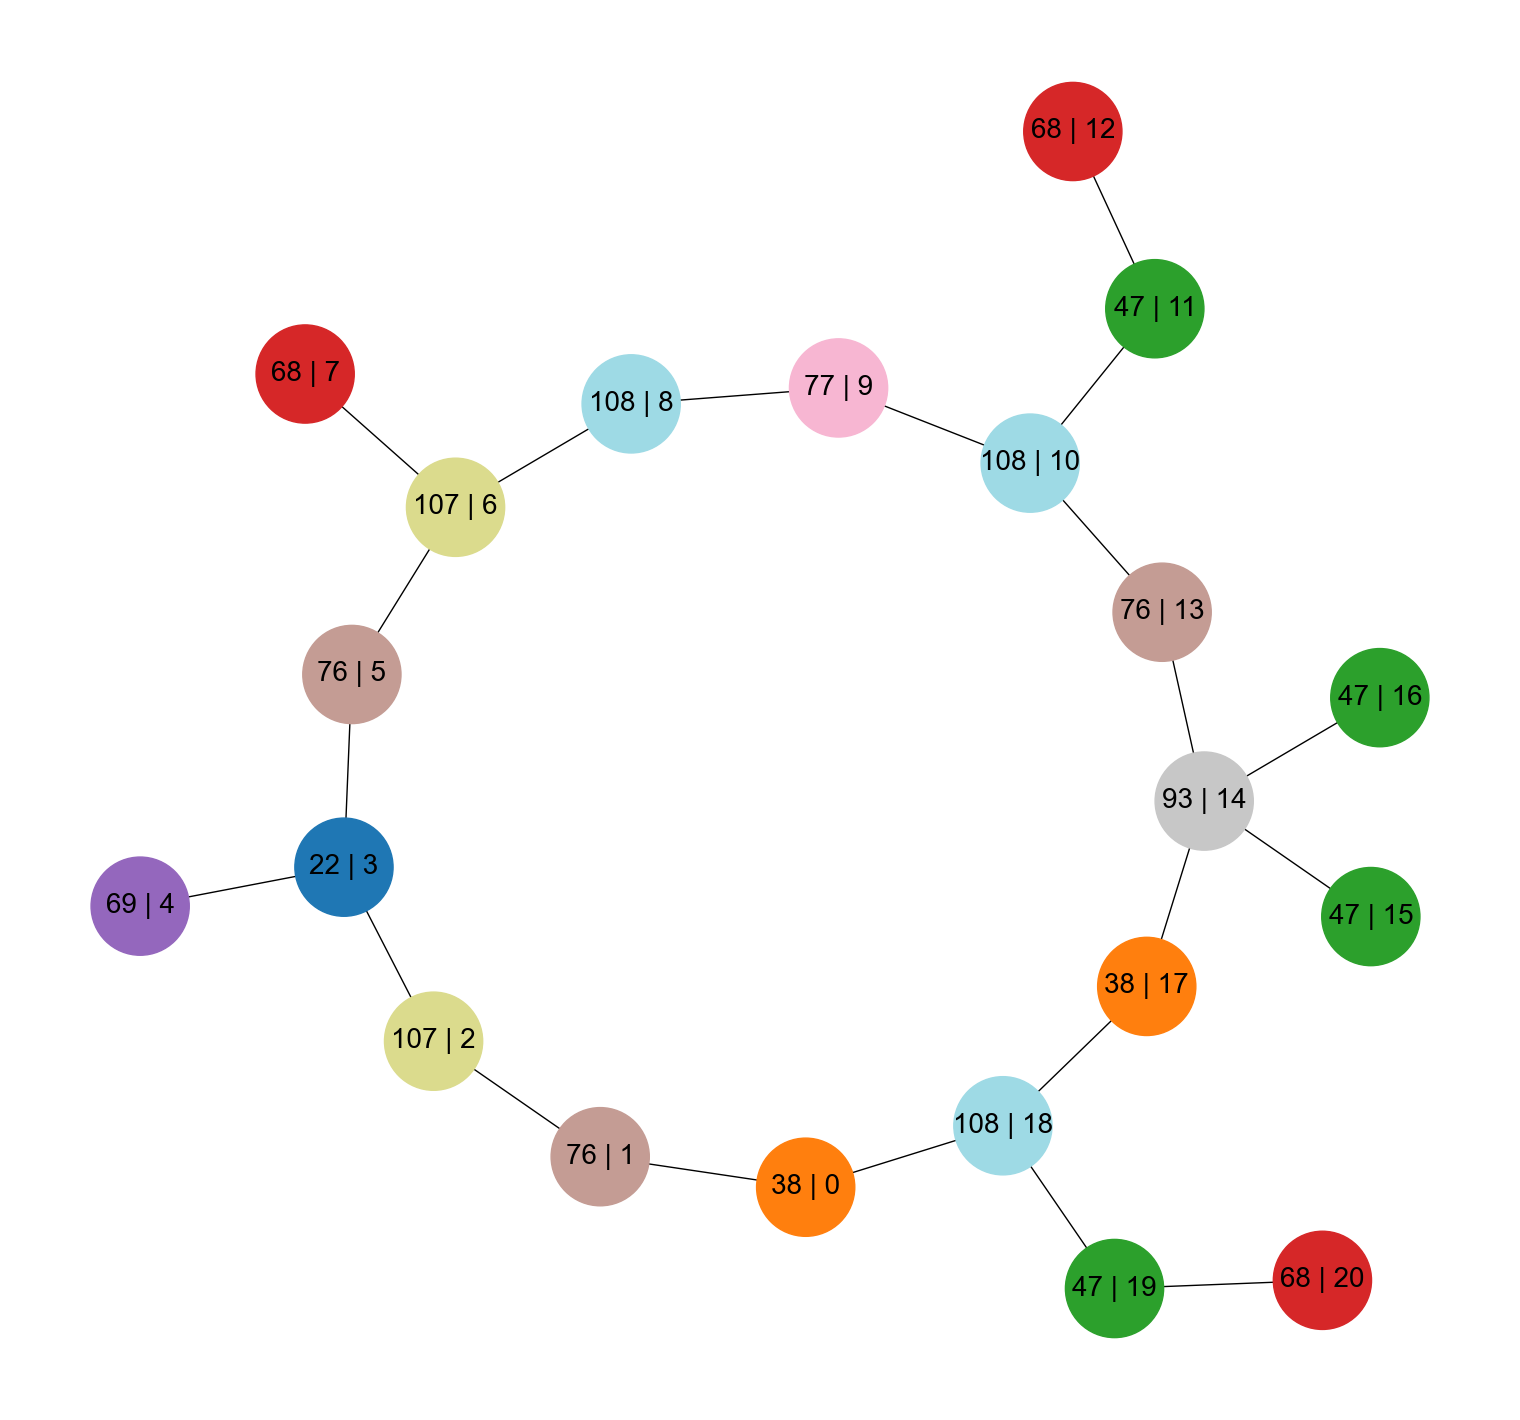

In [9]:
# Visualize the compound graph with RDKit-style layout
cg.plot_graph_rd_c_style(
    flip_x=True,
    label_fmt="{group} | {idx}",  # Show: fragment_id | node_index
    node_size=5000,
    font_size=20,
    figsize=(15, 14),
    rotate=360/12  # Slight rotation for better view
)

### Understanding the Plot:

- Each **node** (circle) represents a molecular fragment
- **Labels** show: `fragment_id | node_index`
  - Fragment ID: Position in vocabulary (e.g., 38, 76, 107)
  - Node index: Position in this specific graph (0, 1, 2, ...)
- **Edges** (lines) show bonds between fragments
- **Layout** follows the 2D structure of the molecule

### Customizing Labels:

You can use different label formats:
```python
label_fmt="{group}"          # Just fragment ID
label_fmt="{idx}"            # Just node index
label_fmt="{smiles}"         # Fragment SMILES
label_fmt="{group}\n{smiles}" # Multi-line labels
```

## 8. Comparing with Fragment Highlighting

GSGE provides **fragment highlighting** on the original molecular structure. To understand the relationship between the two views, we generate both with **coordinated colors** — the same fragment gets the same color in both the molecular highlight and the compound graph.

### Approach:

1. Call `plot_GS_fragments_in_mol` with `return_color_info=True` to get a fragment ID → color mapping
2. Pass that color mapping to `plot_graph_rd_c_style` via `node_color_map`
3. Display both side by side for direct visual comparison

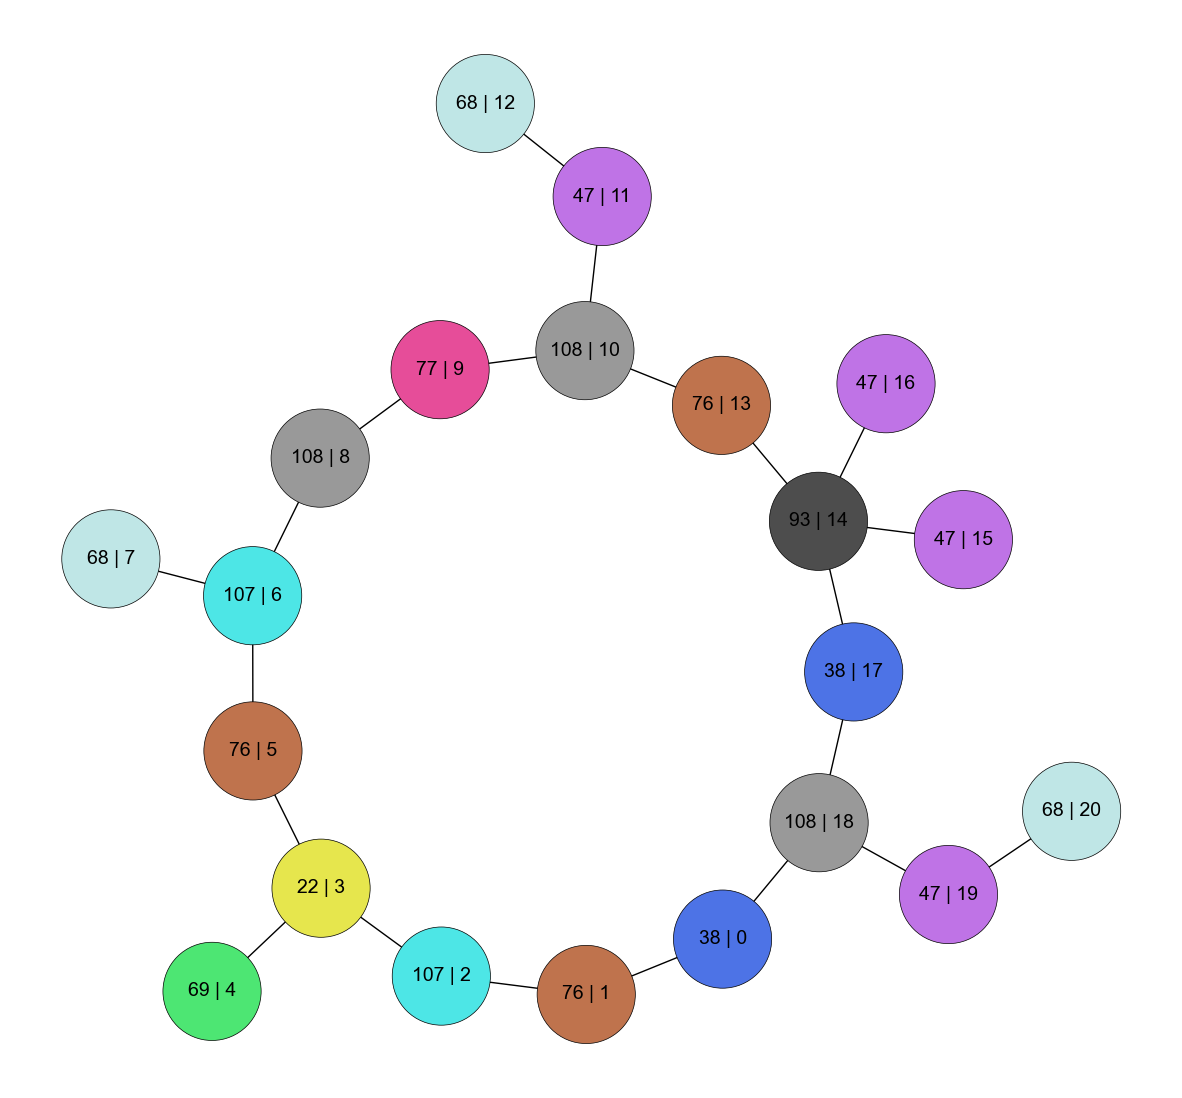

[OK] Saved compound graph to figures/compound_graph.[svg|png|pdf]


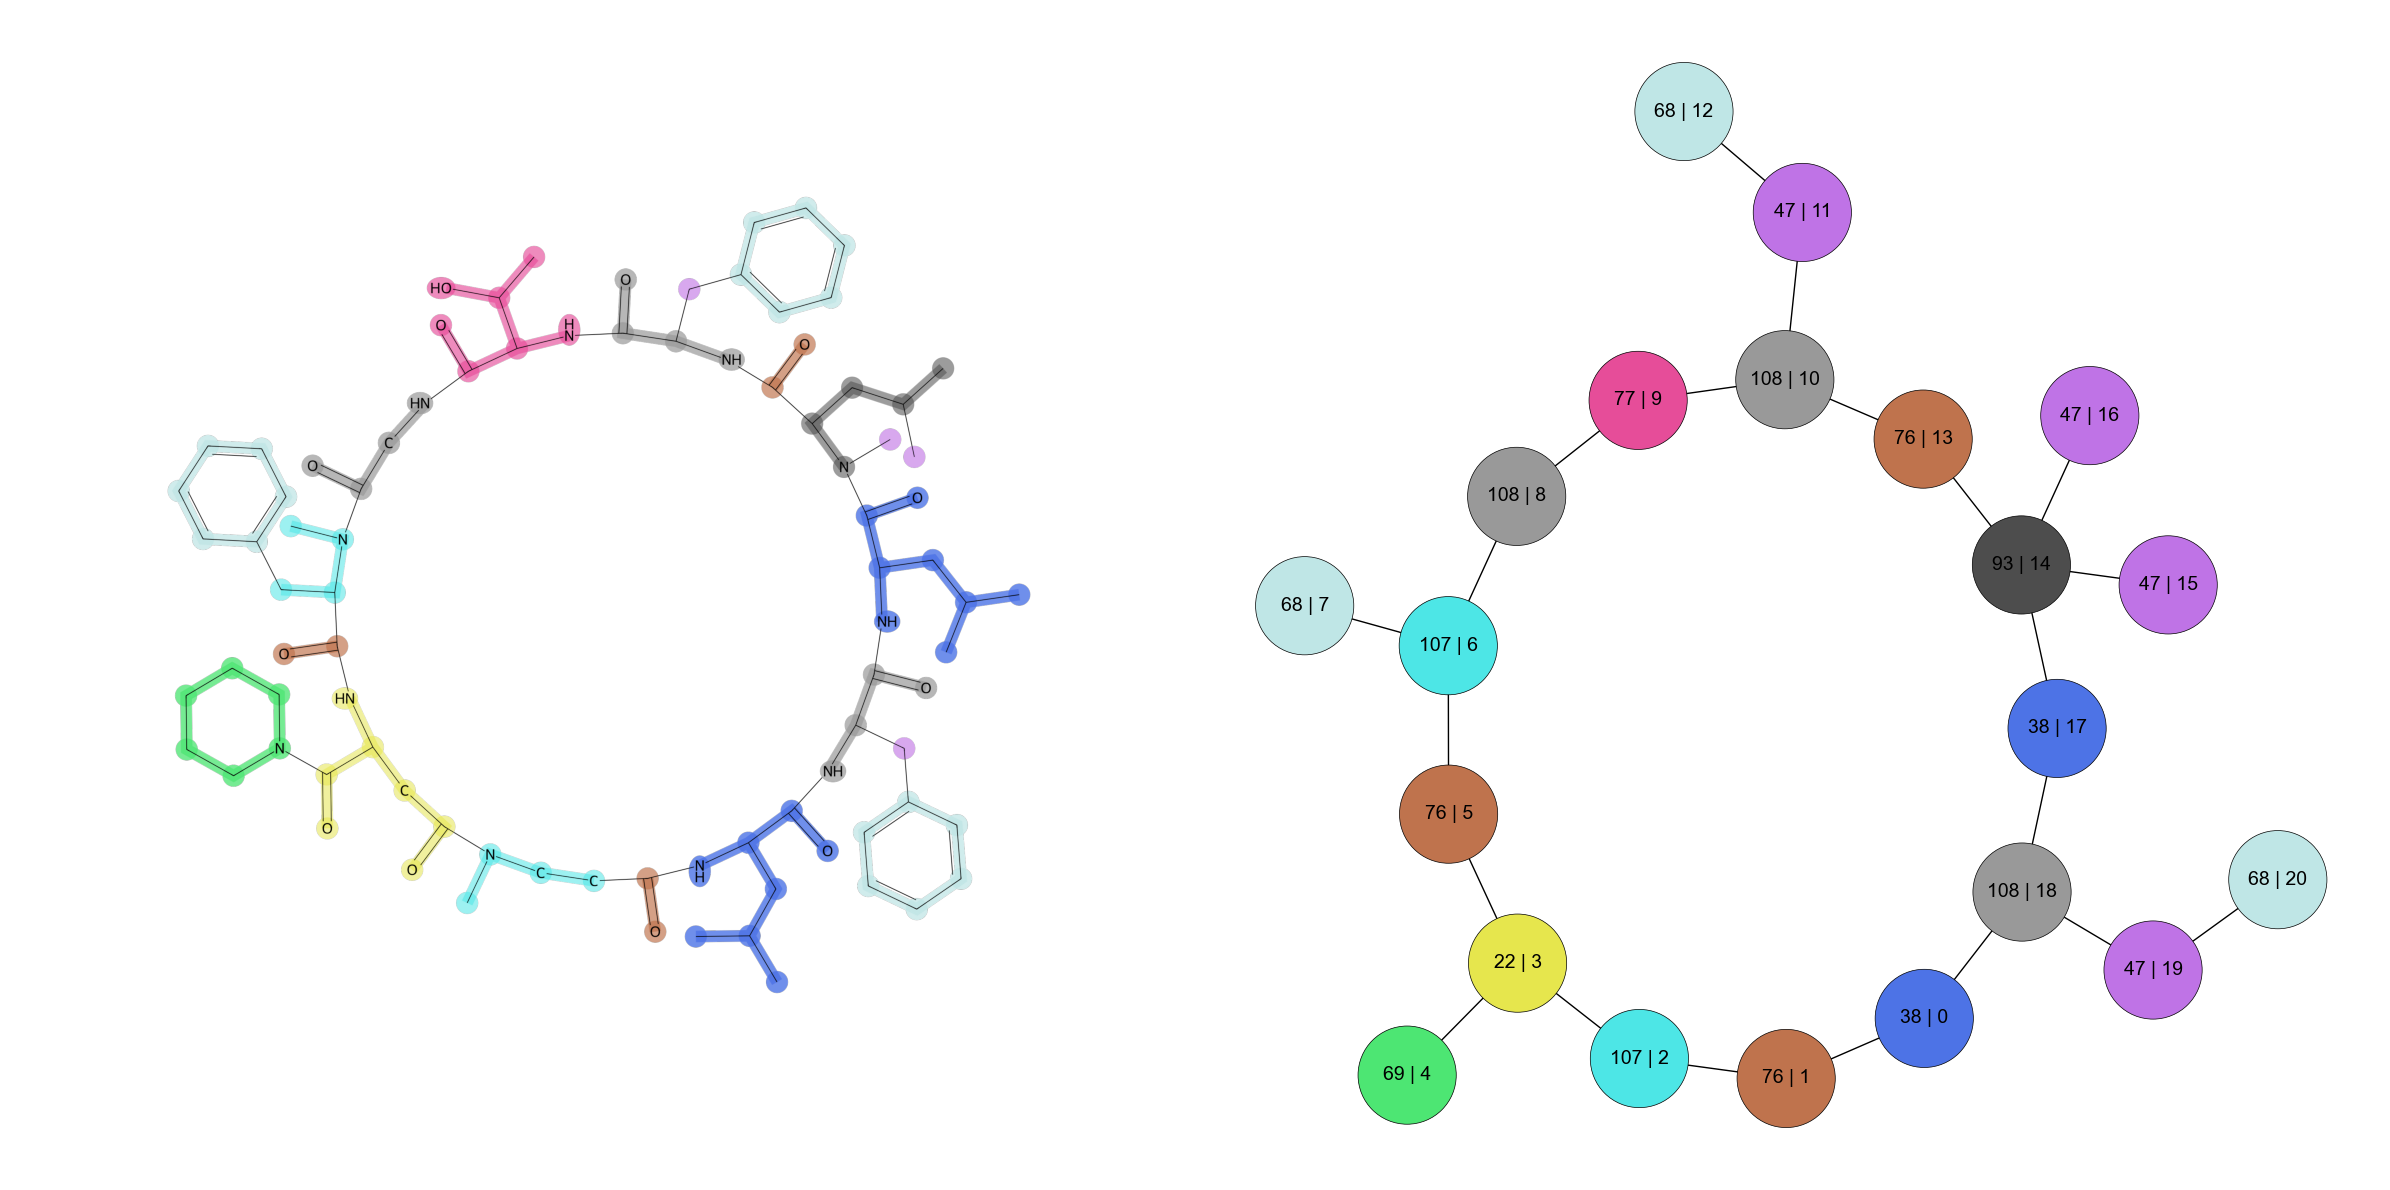

Both views show peptide_smiles[0] with 21 fragment nodes.
Colors are coordinated: same fragment ID -> same color in both views.
[OK] Saved side-by-side to figures/fragment_comparison_side_by_side.[svg|png|pdf]


In [20]:
# Step 2: Display side by side - highlighted molecule + compound graph with matching colors
from rdkit import Chem
from rdkit.Chem import AllChem
import networkx as nx
import numpy as np

node_ids, edge_index, bond_index = cg.get_graph_data()

# Build adjacency and NetworkX graph
n_nodes = len(node_ids)
adj_matrix = np.zeros((n_nodes, n_nodes), dtype=int)
for src, tgt in zip(edge_index[0], edge_index[1]):
    adj_matrix[src, tgt] = 1
G = nx.from_numpy_array(adj_matrix)

# RDKit 2D layout (same approach as plot_graph_rd_c_style)
mol = Chem.RWMol()
for _ in range(n_nodes):
    mol.AddAtom(Chem.Atom(6))
for i in range(n_nodes):
    for j in range(i + 1, n_nodes):
        if adj_matrix[i, j] > 0:
            mol.AddBond(i, j, Chem.BondType.SINGLE)
AllChem.Compute2DCoords(mol)
conf = mol.GetConformer()
pos = {}
rotate = 0  # degrees counter-clockwise (after flip_x)
theta = np.radians(rotate)
for i in range(n_nodes):
    x, y = conf.GetAtomPosition(i).x, conf.GetAtomPosition(i).y
    x, y = x * np.cos(theta) - y * np.sin(theta), x * np.sin(theta) + y * np.cos(theta)
    pos[i] = (-x, y)  # flip_x=True

labels = {i: f"{node_ids[i]} | {i}" for i in range(n_nodes)}
# Make node colors fully opaque (strip alpha, use RGB only)
node_colors = [frag_color_map.get(nid, (0.7, 0.7, 0.7, 1.0))[:3] for nid in node_ids]

def draw_graph_layered(G, pos, ax, labels, node_colors, node_size=5000, font_size=14):
    """Draw graph with edges behind nodes (layered rendering), no axes/grid."""
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color="black", width=1.0)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=node_size, node_color=node_colors, edgecolors="black", linewidths=0.5)
    nx.draw_networkx_labels(G, pos, labels=labels, ax=ax, font_size=font_size)
    ax.axis('off')

# --- Save compound graph standalone ---
fig_graph, ax_graph = plt.subplots(figsize=(15, 14))
fig_graph.patch.set_alpha(0)
draw_graph_layered(G, pos, ax_graph, labels, node_colors, node_size=5000, font_size=14)
save_figure(fig_graph, fig_dir / 'compound_graph', dpi=300, formats=['svg', 'png', 'pdf'])
plt.show()
print("[OK] Saved compound graph to figures/compound_graph.[svg|png|pdf]")

# --- Save side-by-side comparison ---
fig, axes = plt.subplots(1, 2, figsize=(24, 12))
fig.patch.set_alpha(0)

axes[0].imshow(mol_img)
axes[0].axis('off')

draw_graph_layered(G, pos, axes[1], labels, node_colors, node_size=5000, font_size=14)

plt.tight_layout()
save_figure(fig, fig_dir / 'fragment_comparison_side_by_side', dpi=300, formats=['svg', 'png', 'pdf'])
plt.show()

print(f"Both views show peptide_smiles[0] with {n_nodes} fragment nodes.")
print("Colors are coordinated: same fragment ID -> same color in both views.")
print("[OK] Saved side-by-side to figures/fragment_comparison_side_by_side.[svg|png|pdf]")


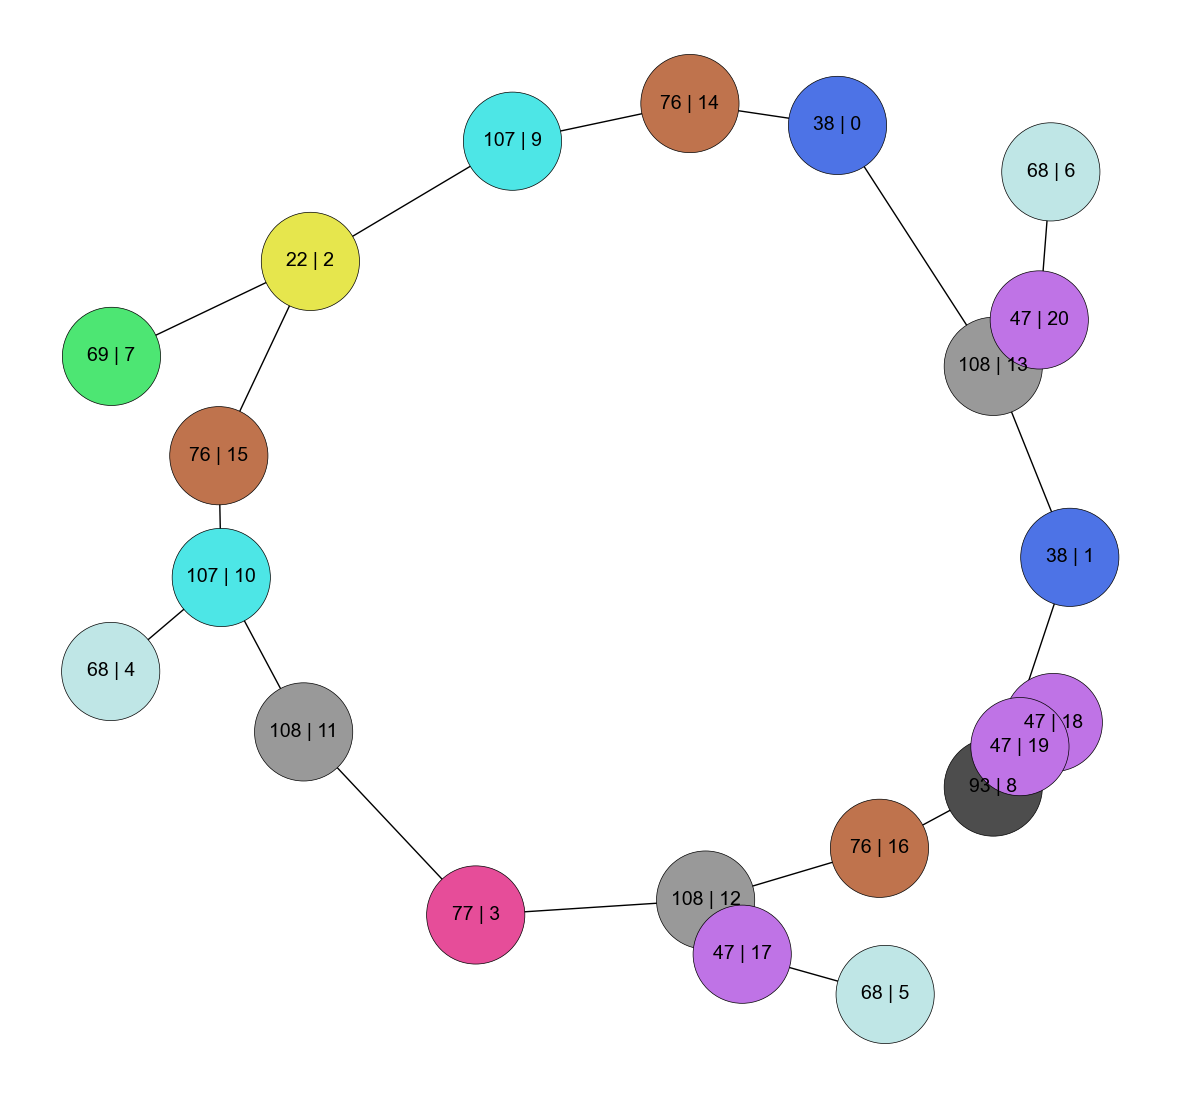

[OK] Saved compound graph to figures/compound_graph.[svg|png|pdf]


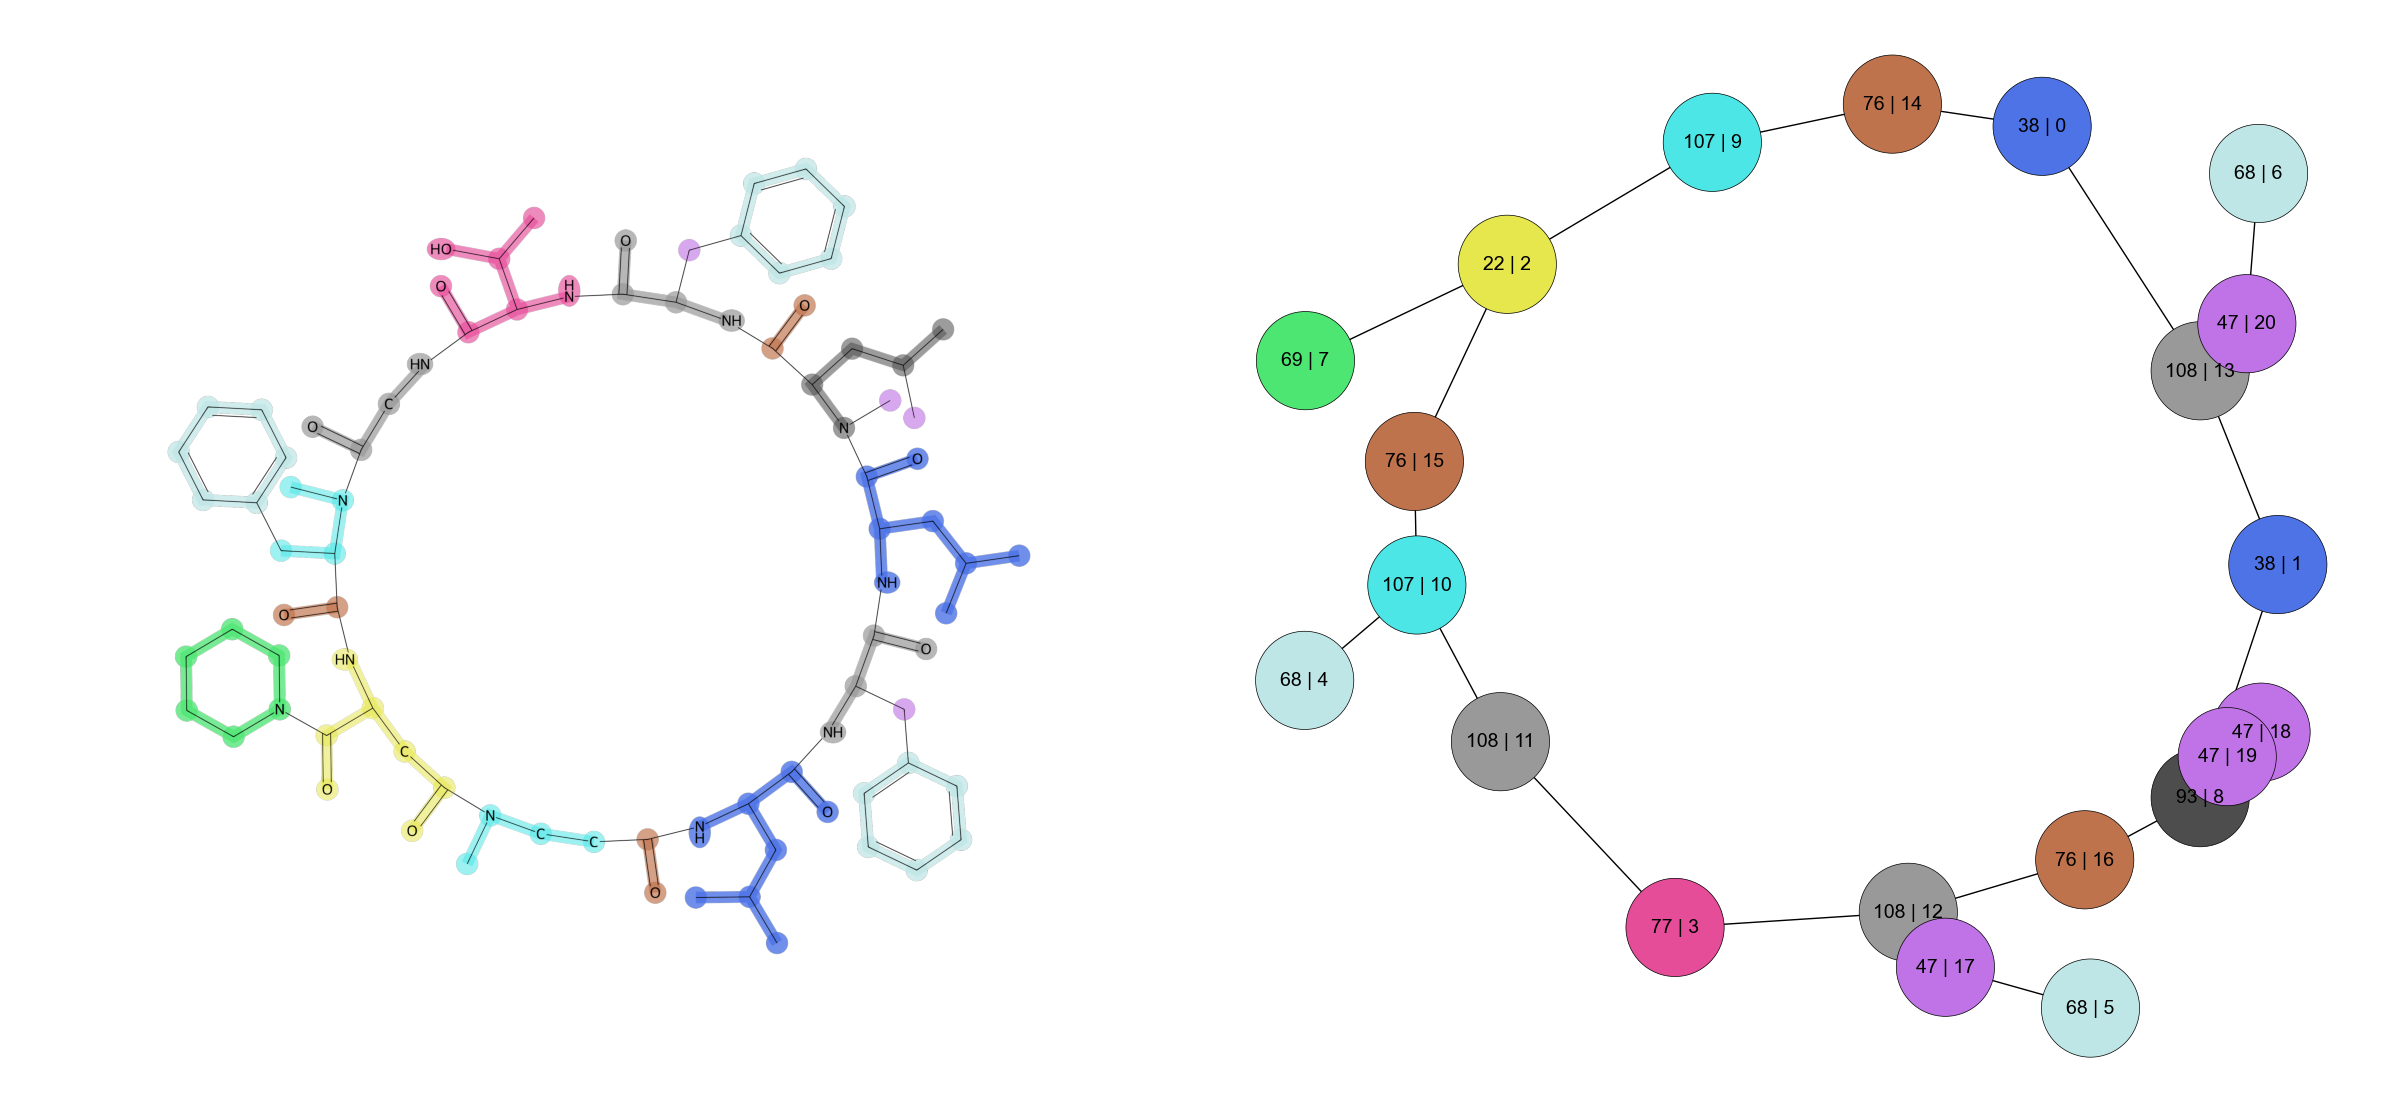

Both views show peptide_smiles[0] with 21 fragment nodes.
Colors are coordinated: same fragment ID -> same color in both views.
[OK] Saved side-by-side to figures/fragment_comparison_side_by_side.[svg|png|pdf]


In [18]:
# Step 2: Display side by side - highlighted molecule + compound graph with matching colors
# Node positions are computed from fragment atom centroids in the real molecule's 2D layout,
# so the graph orientation matches the highlighted molecule on the left.
from rdkit import Chem
from rdkit.Chem import AllChem
import networkx as nx
import numpy as np

# Compute 2D layout on the real molecule (same SMILES used for highlighting)
real_mol = Chem.MolFromSmiles(peptide_smiles[0])
AllChem.Compute2DCoords(real_mol)
conf_real = real_mol.GetConformer()
atom_pos = np.array(
    [[conf_real.GetAtomPosition(i).x, conf_real.GetAtomPosition(i).y]
     for i in range(real_mol.GetNumAtoms())]
)

# Use cg.groups in original order so node i corresponds directly to cg.groups[i].member_idxs.
groups = cg.groups
n_nodes = len(groups)
node_ids = [int(g.name.rsplit('_', 1)[-1]) for g in groups]

# Build adjacency from the raw bond index (same source the compound graph uses internally)
adj_matrix = np.zeros((n_nodes, n_nodes), dtype=int)
for bond_groups in cg._get_bond_index():
    for a in range(len(bond_groups)):
        for b in range(a + 1, len(bond_groups)):
            i, j = bond_groups[a], bond_groups[b]
            adj_matrix[i, j] = 1
            adj_matrix[j, i] = 1

G = nx.from_numpy_array(adj_matrix)

# Position each fragment node at the centroid of its atoms in the real mol's 2D layout.
# Flip Y so the graph matches the RDKit image (image y-axis points down).
pos = {}
for i, group in enumerate(groups):
    member_ids = list(group.member_idxs)
    centroid = atom_pos[member_ids].mean(axis=0)
    pos[i] = (float(centroid[0]), float(-centroid[1]))

labels = {i: f"{node_ids[i]} | {i}" for i in range(n_nodes)}
node_colors = [frag_color_map.get(nid, (0.7, 0.7, 0.7, 1.0))[:3] for nid in node_ids]


def draw_graph_layered(G, pos, ax, labels, node_colors, node_size=5000, font_size=14):
    """Draw graph with edges behind nodes (layered rendering), no axes/grid."""
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color="black", width=1.0)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=node_size, node_color=node_colors, edgecolors="black", linewidths=0.5)
    nx.draw_networkx_labels(G, pos, labels=labels, ax=ax, font_size=font_size)
    ax.set_aspect('equal')
    ax.axis('off')


# --- Save compound graph standalone ---
fig_graph, ax_graph = plt.subplots(figsize=(15, 14))
fig_graph.patch.set_alpha(0)
draw_graph_layered(G, pos, ax_graph, labels, node_colors, node_size=5000, font_size=14)
save_figure(fig_graph, fig_dir / 'compound_graph', dpi=300, formats=['svg', 'png', 'pdf'])
plt.show()
print("[OK] Saved compound graph to figures/compound_graph.[svg|png|pdf]")

# --- Save side-by-side comparison ---
fig, axes = plt.subplots(1, 2, figsize=(24, 12))
fig.patch.set_alpha(0)

axes[0].imshow(mol_img)
axes[0].axis('off')

draw_graph_layered(G, pos, axes[1], labels, node_colors, node_size=5000, font_size=14)

plt.tight_layout()
save_figure(fig, fig_dir / 'fragment_comparison_side_by_side', dpi=300, formats=['svg', 'png', 'pdf'])
plt.show()

print(f"Both views show peptide_smiles[0] with {n_nodes} fragment nodes.")
print("Colors are coordinated: same fragment ID -> same color in both views.")
print("[OK] Saved side-by-side to figures/fragment_comparison_side_by_side.[svg|png|pdf]")


### Understanding the Side-by-Side Comparison:

**Left panel (Fragment Highlighting):**
- Shows the original molecular structure with atoms colored by fragment membership
- Annotations: `atom_idx(frag_idx|frag_id)` — atom index, fragment position, vocabulary ID
- Bonds within a fragment share the fragment's color

**Right panel (Compound Graph):**
- Each node represents one fragment, labeled `frag_id | node_idx`
- Edges show bonds between fragments
- Layout follows RDKit's 2D coordinate computation for the graph topology

**Matching colors:** Both panels use the same color for the same fragment vocabulary ID, so you can visually trace which group of atoms in the molecule corresponds to which node in the graph.

> **Tip:** Use `node_color_map` parameter in `plot_graph_rd_c_style()` and `fragment_colors` / `return_color_info` in `plot_GS_fragments_in_mol()` to coordinate colors in your own analyses.

## 9. Using Graphs for GNN Training

Compound graphs can be used directly with PyTorch Geometric for training Graph Neural Networks. Here's a complete example workflow:

### Typical GNN Training Pipeline:

1. Create compound graphs for your dataset
2. Add labels/properties to each graph
3. Create PyG DataLoader
4. Define GNN model
5. Train and evaluate

In [12]:
# Example: Preparing graphs for GNN training

# Step 1: Create graphs with PyG format
graphs = gsge.make_compound_graphs(peptide_smiles, pyg_data=True, workers=8)

# Step 2: Add properties/labels (example: random labels for demonstration)
import torch
for graph in graphs:
    graph.y = torch.tensor([0])  # Replace with actual property values

# Step 3: Create DataLoader
from torch_geometric.loader import DataLoader

# Split into train/test
train_graphs = graphs[:10]
test_graphs = graphs[10:]

train_loader = DataLoader(train_graphs, batch_size=4, shuffle=True)
test_loader = DataLoader(test_graphs, batch_size=4, shuffle=False)

print(f"[OK] DataLoader created")
print(f"  - Training batches: {len(train_loader)}")
print(f"  - Test batches: {len(test_loader)}")

parallel_tokenize_batch: 100%|██████████| 14/14 [00:46<00:00,  3.30s/it]


[OK] DataLoader created
  - Training batches: 3
  - Test batches: 1


### Example GNN Model:

Here's a simple GNN model that works with compound graphs:

In [13]:
from torch_geometric.nn import GCNConv, global_mean_pool
import torch.nn.functional as F

class CompoundGraphGNN(torch.nn.Module):
    def __init__(self, num_fragments, hidden_dim, num_classes):
        super().__init__()
        # Embedding layer for fragment IDs
        self.embedding = torch.nn.Embedding(num_fragments, hidden_dim)
        
        # GNN layers
        self.conv1 = GCNConv(hidden_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.conv3 = GCNConv(hidden_dim, hidden_dim)
        
        # Prediction head
        self.fc = torch.nn.Linear(hidden_dim, num_classes)
    
    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        
        # Embed fragment IDs
        x = self.embedding(x)
        
        # GNN layers with ReLU activation
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = F.relu(self.conv3(x, edge_index))
        
        # Global pooling (aggregate node features)
        x = global_mean_pool(x, batch)
        
        # Prediction
        return self.fc(x)

# Create model
model = CompoundGraphGNN(
    num_fragments=gsge.get_GS_vocab().num_fragments + 100,  # Vocabulary size + buffer
    hidden_dim=128,
    num_classes=1  # For regression, use 1; for classification, use num_classes
)

print(f"[OK] GNN model created")
print(f"  - Parameters: {sum(p.numel() for p in model.parameters()):,}")

[OK] GNN model created
  - Parameters: 86,145


### Using Pre-trained Fragment Embeddings:

If you've trained a GAE (Graph Autoencoder), you can use the learned embeddings instead of training from scratch:

In [14]:
# Load pre-trained fragment embeddings from GAE
fragment_embeddings = gsge.get_fragment_embeddings()

if fragment_embeddings is not None:
    print(f"[OK] Pre-trained embeddings available")
    print(f"  - Embedding shape: {fragment_embeddings.shape}")
    print(f"  - Dimension: {fragment_embeddings.shape[1]}")
    
    # You can initialize the embedding layer with these
    # model.embedding.weight.data[:len(fragment_embeddings)] = torch.FloatTensor(fragment_embeddings)
    # model.embedding.weight.requires_grad = False  # Freeze if you don't want to fine-tune
else:
    print("[!] No pre-trained embeddings available. Train embeddings from scratch or run GAE training first.")

[OK] Pre-trained embeddings available
  - Embedding shape: torch.Size([185, 128])
  - Dimension: 128


## 10. Summary and Next Steps

### What You Learned:

[OK] **Compound graphs**: Represent molecules as fragment-level graphs

[OK] **PyG Data format**: Efficient format for GNN training with PyTorch Geometric

[OK] **Batch processing**: Generate graphs for multiple molecules in parallel

[OK] **Visualization**: Understand graph structure and fragment decomposition

[OK] **GNN integration**: Use compound graphs with Graph Neural Networks

[OK] **Pre-trained embeddings**: Leverage learned fragment representations

### Key Takeaways:

1. **Compound graphs** operate at the fragment level, not atom level
2. **Fragment-based GNNs** can learn from functional group patterns
3. **Pre-trained embeddings** (from GAE) improve performance
4. **Visualization** helps validate fragmentation and graph structure

## Next Steps

Now that you can create compound graphs, explore:

1. **Train GAE**: Learn fragment embeddings from your data
   - See: [`../03_GAE/README.md`](../03_GAE/README.md)

2. **Use Embeddings**: Apply learned embeddings in downstream tasks
   - See: [`../04_use_embeddings/README.md`](../04_use_embeddings/README.md)

3. **Build Vocabularies**: Create custom vocabularies for your chemical space
   - See: [`../00_making_vocabs/README.md`](../00_making_vocabs/README.md)

4. **Property Prediction**: Train GNN models for molecular property prediction

5. **Virtual Screening**: Use graph similarity for screening large libraries

## Additional Resources

- [Tutorial README](README.md) - Overview and quick start guide
- [PyTorch Geometric Documentation](https://pytorch-geometric.readthedocs.io/) - GNN framework
- [GSGE Documentation](../../docs/index.md) - Complete package documentation
- [API Reference](../../docs/api-reference/index.md) - Detailed API docs

---

**Questions or issues?** Open an issue on [GitHub](https://github.com/CDDLeiden/GSGE/issues)